# Notebook 1: Datengenerierung für Novelty Detection mit dem TCLab

## Ziel dieses Notebooks

In diesem Notebook wird eine strukturierte Bibliothek von Normalbetriebsdaten für das Temperature Control Lab (TCLab) aufgebaut. Diese Daten dienen als Grundlage für spätere Verfahren der Fault Detection, Anomaly Detection und Novelty Detection.

Im Mittelpunkt stehen:

- zwei Heizelemente $Q_1$ und $Q_2$
- zwei Temperatursensoren $T_1$ und $T_2$
- eine kontrollierte Profilbibliothek mit mehreren Profilfamilien
- Datengenerierung mit dem TCLab-Modell
- optional dieselbe Datengenerierung mit echter Hardware
- ein einheitliches Speicherformat für spätere ML- und DL-Notebooks

<div style="border:2px solid #777; border-radius:8px; padding:12px; background:#f7f7f7; margin:12px 0;">
<b>Merksatz:</b> In diesem Notebook werden direkte Heizprofile für $Q_1$ und $Q_2$ verwendet. Temperatur-Sollwertprofile mit einem Regler werden hier bewusst noch nicht eingesetzt.
</div>

## Einordnung in die Notebook-Reihe

Dieses Notebook ist der erste Teil einer dreiteiligen Reihe:

1. Datengenerierung und Aufbau eines NOC-Datensatzes
2. Offline-ML/DL für Novelty Detection auf Simulationsdaten
3. Transfer auf reale Hardware und Nachtraining


## Lehr- und Nutzungshinweise

Dieses Notebook ist als Lehr- und Arbeitsnotebook für die Hochschullehre gedacht.

- Die Markdown-Texte und die Notebookstruktur können für die Lehre angepasst werden.
- Der Python-Code ist so geschrieben, dass er für spätere Notebooks weiterverwendet werden kann.
- Modell- und Hardwaredaten werden im gleichen Grundformat gespeichert, aber nach Quelle getrennt abgelegt.

<div style="border:2px solid #777; border-radius:8px; padding:12px; background:#f7f7f7; margin:12px 0;">
<b>Definition:</b> NOC steht für <b>Normal Operating Conditions</b>. Gemeint ist hier ein breiter, aber kontrollierter Bereich normalen thermischen Betriebs.
</div>


In [3]:
# Standardbibliotheken
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Tuple

# Datenverarbeitung
import numpy as np
import pandas as pd

# Visualisierung
import matplotlib.pyplot as plt

# Notebook-Anzeige
from IPython.display import display

# TCLab
try:
    import tclab
    TCLAB_AVAILABLE = True
except Exception:
    tclab = None
    TCLAB_AVAILABLE = False

# Reproduzierbarkeit
GLOBAL_RANDOM_SEED = 42
rng = np.random.default_rng(GLOBAL_RANDOM_SEED)

print("tclab verfügbar:", TCLAB_AVAILABLE)


tclab verfügbar: True


## Konfiguration

In diesem Abschnitt werden alle zentralen Parameter des Notebooks an einer Stelle definiert. Dadurch bleiben Datengenerierung, Export und spätere Wiederverwendung nachvollziehbar.

## Hinweis zur Datensatzversion und Speicherung

Für jede neue Datenerzeugung **MUSS** eine neue Datensatzversion vergeben werden, zum Beispiel `v0_2`, `v0_3` oder `v1_0`.

**Merksatz:** Eine neue Mess- oder Simulationskampagne erhält eine eigene Version des Datensatzes.

- zu jeder Version gehören die passenden Metadaten
- Konfiguration, Profilbibliothek und Exportzustand bleiben konsistent dokumentiert
- spätere Vergleiche zwischen verschiedenen Datensätzen werden einfacher

Praktisch bedeutet das:

- vor einem neuen Lauf `dataset_version` in der Konfiguration anpassen
- optional auch den Exportpfad anpassen, falls verschiedene Versuchsreihen getrennt werden sollen

Beispiel:

```python
CONFIG["dataset_version"] = "v0"


In [5]:
# ============================================================
# Zentrale Konfiguration
# ============================================================

CONFIG: Dict[str, Any] = {
    # Modus
    "use_model": False,
    "use_hardware": False,

    # Zeit
    "sample_time_s": 1.0,
    "run_duration_s": 600,
    "initial_hold_range_s": (20, 30),
    "cooldown_duration_s": 60,  # Mindestdauer mit Q1=0 und Q2=0 am Run-Ende

    # Anzahl Runs
    "n_runs_model": 248,
    "n_runs_hardware": 24,

    # Hardware-Startlogik
    "hardware_start_temp_tolerance_degC": 1.5,
    "hardware_stability_window_s": 20,
    "hardware_stability_max_slope_degC_per_s": 0.03,
    "hardware_wait_check_interval_s": 2,

    # Heizgrenzen
    "q1_min": 0.0,
    "q1_max": 100.0,
    "q2_min": 0.0,
    "q2_max": 100.0,

    # Modell / Simulation
    "simulation_speedup": 100,

    # Visualisierung
    "plot_example_runs": 6,
    "plot_family_overlays": True,
    "max_overlay_runs_per_family": 5,

    # Export
    "dataset_name": "tclab_data_noc",
### Hier die Version eintragen!!!
    "dataset_version": "v1",
###
    "export_base_dir": "data",
    "write_parquet": True,
    "write_csv_fallback": True,
    "write_json_config": True,

    # Randomness / Diversität
    "random_seed": GLOBAL_RANDOM_SEED,
    "max_generation_attempts_per_run": 50,
}

# Lokalen Zufallsgenerator mit Konfig-Seed neu initialisieren
rng = np.random.default_rng(CONFIG["random_seed"])

CONFIG


{'use_model': False,
 'use_hardware': True,
 'sample_time_s': 1.0,
 'run_duration_s': 600,
 'initial_hold_range_s': (20, 30),
 'cooldown_duration_s': 60,
 'n_runs_model': 248,
 'n_runs_hardware': 24,
 'hardware_start_temp_tolerance_degC': 1.5,
 'hardware_stability_window_s': 20,
 'hardware_stability_max_slope_degC_per_s': 0.03,
 'hardware_wait_check_interval_s': 2,
 'q1_min': 0.0,
 'q1_max': 100.0,
 'q2_min': 0.0,
 'q2_max': 100.0,
 'simulation_speedup': 100,
 'plot_example_runs': 6,
 'plot_family_overlays': True,
 'max_overlay_runs_per_family': 5,
 'dataset_name': 'tclab_data_noc',
 'dataset_version': 'v1',
 'export_base_dir': 'data',
 'write_parquet': True,
 'write_csv_fallback': True,
 'write_json_config': True,
 'random_seed': 42,
 'max_generation_attempts_per_run': 50}

## Datenstruktur und Speicherformat

Die erzeugten Daten werden in drei Ebenen gespeichert:

1. Zeitreihentabelle  
   Eine Zeile entspricht einem Zeitschritt eines Runs.

2. Run-Metadaten-Tabelle  
   Eine Zeile entspricht einem vollständigen Run.

3. JSON-Konfigurationsdateien  
   Enthalten zentrale Einstellungen und die Profilbibliothek.



In [7]:
# ============================================================
# Pfade und Ordnerstruktur
# ============================================================

EXPORT_BASE_DIR = Path(CONFIG["export_base_dir"]) / CONFIG["dataset_version"]

TIMESERIES_DIR = EXPORT_BASE_DIR / "timeseries"
METADATA_DIR = EXPORT_BASE_DIR / "run_metadata"
CONFIG_DIR = EXPORT_BASE_DIR / "config"
PLOTS_DIR = EXPORT_BASE_DIR / "plots"

for path in [TIMESERIES_DIR, METADATA_DIR, CONFIG_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Exportverzeichnis:", EXPORT_BASE_DIR.resolve())


Exportverzeichnis: D:\Data_Code\Code\1 Code - Process control\1Code AIPC - Chaos\TCLab chaos coding\20260401_TCLab_FDD\data\v1


In [8]:
# ============================================================
# Erwartete Datenspalten
# ============================================================

TIMESERIES_COLUMNS = [
    "run_id",
    "source",
    "profile_family",
    "profile_variant",
    "sample_time_s",
    "t_sec",
    "Q1",
    "Q2",
    "T1",
    "T2",
    "ambient_ref",
    "phase",
    "split",
    "run_ok",
    "notes",
]

RUN_METADATA_COLUMNS = [
    "run_id",
    "source",
    "profile_family",
    "profile_variant",
    "duration_s",
    "sample_time_s",
    "initial_hold_s",
    "cooldown_s",
    "seed",
    "ambient_ref_start",
    "t1_start",
    "t2_start",
    "t1_end",
    "t2_end",
    "q1_mean",
    "q1_max",
    "q2_mean",
    "q2_max",
    "n_segments_q1",
    "n_segments_q2",
    "coordination_mode",
    "contains_short_segment",
    "profile_signature",
    "run_ok",
    "comment",
]

TIMESERIES_COLUMNS, RUN_METADATA_COLUMNS[:8]


(['run_id',
  'source',
  'profile_family',
  'profile_variant',
  'sample_time_s',
  't_sec',
  'Q1',
  'Q2',
  'T1',
  'T2',
  'ambient_ref',
  'phase',
  'split',
  'run_ok',
  'notes'],
 ['run_id',
  'source',
  'profile_family',
  'profile_variant',
  'duration_s',
  'sample_time_s',
  'initial_hold_s',
  'cooldown_s'])

## Profilbibliothek

Für die Datengenerierung werden vier Profilfamilien verwendet:

1. versetzte Treppenprofile
2. Q1-dominante Profile
3. Q2-dominante Profile
4. koordinierte Profile

Unvollständige Plateaus werden nicht als eigene Familie behandelt, sondern als Regel innerhalb mehrerer Familien.


In [10]:
# ============================================================
# Profilbibliothek und Parameterbereiche
# ============================================================

PROFILE_FAMILY_WEIGHTS = {
    "staggered_steps": 10,
    "q1_dominant": 5,
    "q2_dominant": 5,
    "coordinated": 4,
}

PROFILE_LIBRARY: Dict[str, Dict[str, Any]] = {
    "staggered_steps": {
        "description": "Versetzte Treppenprofile für Q1 und Q2",
        "n_segments_range": (4, 5),
        "segment_duration_range_s": (40, 140),
        "offset_range_s": (20, 90),
        "coordination_mode": "staggered",
    },
    "q1_dominant": {
        "description": "Q1 ist Hauptanregung, Q2 begleitet schwächer",
        "n_segments_range": (4, 5),
        "segment_duration_range_s": (40, 150),
        "offset_range_s": (15, 80),
        "coordination_mode": "q1_dominant",
    },
    "q2_dominant": {
        "description": "Q2 ist Hauptanregung, Q1 begleitet schwächer",
        "n_segments_range": (4, 5),
        "segment_duration_range_s": (40, 150),
        "offset_range_s": (15, 80),
        "coordination_mode": "q2_dominant",
    },
    "coordinated": {
        "description": "Q1 und Q2 werden abschnittsweise gleichsinnig oder gegensinnig verändert",
        "n_segments_range": (4, 5),
        "segment_duration_range_s": (40, 130),
        "offset_range_s": (0, 30),
        "coordination_mode": "coordinated",
    },
}

PROFILE_LIBRARY


{'staggered_steps': {'description': 'Versetzte Treppenprofile für Q1 und Q2',
  'n_segments_range': (4, 5),
  'segment_duration_range_s': (40, 140),
  'offset_range_s': (20, 90),
  'coordination_mode': 'staggered'},
 'q1_dominant': {'description': 'Q1 ist Hauptanregung, Q2 begleitet schwächer',
  'n_segments_range': (4, 5),
  'segment_duration_range_s': (40, 150),
  'offset_range_s': (15, 80),
  'coordination_mode': 'q1_dominant'},
 'q2_dominant': {'description': 'Q2 ist Hauptanregung, Q1 begleitet schwächer',
  'n_segments_range': (4, 5),
  'segment_duration_range_s': (40, 150),
  'offset_range_s': (15, 80),
  'coordination_mode': 'q2_dominant'},
 'coordinated': {'description': 'Q1 und Q2 werden abschnittsweise gleichsinnig oder gegensinnig verändert',
  'n_segments_range': (4, 5),
  'segment_duration_range_s': (40, 130),
  'offset_range_s': (0, 30),
  'coordination_mode': 'coordinated'}}

## Hilfsfunktionen für Profilerzeugung

Die Profilerzeugung verfolgt drei Ziele:

- ausreichende Variation im Normalbetrieb
- gute Interpretierbarkeit der Profile
- möglichst wenige nahezu identische Runs


In [12]:
# ============================================================
# Dataklasse für einen Profil-Run
# ============================================================

@dataclass
class ProfileRun:
    """Container for one generated profile run."""
    run_id: str
    profile_family: str
    profile_variant: str
    coordination_mode: str
    initial_hold_s: int
    cooldown_s: int
    q1: np.ndarray
    q2: np.ndarray
    contains_short_segment: bool
    n_segments_q1: int
    n_segments_q2: int
    signature: str


In [13]:
# ============================================================
# Allgemeine Hilfsfunktionen
# ============================================================

def weighted_choice(weight_dict: Dict[str, int], rng: np.random.Generator) -> str:
    """Return one key sampled according to integer weights."""
    keys = list(weight_dict.keys())
    weights = np.array(list(weight_dict.values()), dtype=float)
    probs = weights / weights.sum()
    return str(rng.choice(keys, p=probs))


def clamp_array(values: np.ndarray, lower: float, upper: float) -> np.ndarray:
    """Clamp values to a closed interval."""
    return np.clip(values, lower, upper)


def build_time_axis(run_duration_s: int, sample_time_s: float) -> np.ndarray:
    """Create the time axis for one run."""
    return np.arange(0, run_duration_s, sample_time_s, dtype=float)


def build_clock(n_samples: int, sample_time_s: float):
    """Create a TCLab clock with exactly n_samples timestamps."""
    if not TCLAB_AVAILABLE:
        raise RuntimeError("tclab ist nicht verfügbar.")
    final_time_s = (n_samples - 1) * sample_time_s
    return tclab.clock(final_time_s, sample_time_s)


def sample_initial_hold_seconds(rng: np.random.Generator, hold_range: Tuple[int, int]) -> int:
    """Sample the initial hold duration in seconds."""
    low, high = hold_range
    return int(rng.integers(low, high + 1))


def array_to_step_segments(signal: np.ndarray) -> List[Tuple[int, int, float]]:
    """Convert a piecewise constant array into step segments."""
    segments: List[Tuple[int, int, float]] = []
    if len(signal) == 0:
        return segments

    start = 0
    current = signal[0]
    for i in range(1, len(signal)):
        if signal[i] != current:
            segments.append((start, i, float(current)))
            start = i
            current = signal[i]
    segments.append((start, len(signal), float(current)))
    return segments


def shift_signal_right_no_wrap(signal: np.ndarray, shift: int) -> np.ndarray:
    """Shift a signal to the right without wrapping values around."""
    if shift <= 0:
        return signal.copy()

    shifted = np.zeros_like(signal)
    if shift < len(signal):
        shifted[shift:] = signal[:-shift]
    return shifted


In [14]:
# ============================================================
# Segmenterzeugung
# ============================================================

def sample_segment_durations(
    active_duration_s: int,
    n_segments: int,
    duration_range_s: Tuple[int, int],
    rng: np.random.Generator,
    force_short_segment: bool = True,
) -> Tuple[List[int], bool]:
    """
    Sample segment durations in real seconds without normalizing them to the
    full active duration. Remaining time is later filled with zero heating.
    """
    min_dur, max_dur = duration_range_s

    durations = [int(rng.integers(min_dur, max_dur + 1)) for _ in range(n_segments)]
    contains_short_segment = False

    if force_short_segment and n_segments >= 1:
        short_idx = int(rng.integers(0, n_segments))
        durations[short_idx] = int(rng.integers(25, 46))
        contains_short_segment = True

    durations = [max(15, int(d)) for d in durations]

    return durations, contains_short_segment


In [15]:
# ============================================================
# Amplituden- und Signalaufbau
# ============================================================

def sample_level_sequence(
    n_segments: int,
    q_min: float,
    q_max: float,
    rng: np.random.Generator,
    mode: str = "generic",
) -> List[float]:
    """Sample segment levels for one heater channel."""
    levels: List[float] = []

    for _ in range(n_segments):
        if mode == "low_support":
            level = rng.uniform(q_min, min(q_max, 45.0))
        elif mode == "dominant":
            level = rng.uniform(max(q_min, 20.0), q_max)
        else:
            level = rng.uniform(q_min, q_max)

        level = round(level / 5.0) * 5.0
        levels.append(float(level))

    if n_segments >= 3 and len(set(levels)) == 1:
        levels[1] = float(max(q_min, min(q_max, levels[1] + 10.0)))

    return levels


def build_piecewise_constant_signal(
    total_length: int,
    initial_hold_s: int,
    cooldown_s: int,
    durations: List[int],
    levels: List[float],
) -> np.ndarray:
    """Build one heater signal with zero filling until the end of the run."""
    signal = np.zeros(total_length, dtype=float)

    idx = initial_hold_s
    active_stop = total_length - cooldown_s

    for dur, lvl in zip(durations, levels):
        end_idx = min(active_stop, idx + dur)
        signal[idx:end_idx] = lvl
        idx = end_idx
        if idx >= active_stop:
            break

    signal[active_stop:] = 0.0
    return signal


In [16]:
# ============================================================
# Familienlogik
# ============================================================

def generate_profile_by_family(
    family: str,
    run_duration_s: int,
    initial_hold_s: int,
    cooldown_s: int,
    config: Dict[str, Any],
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray, str, bool, int, int]:
    """Generate one (Q1, Q2) pair for a selected profile family."""
    total_length = int(run_duration_s)
    active_duration_s = int(run_duration_s - initial_hold_s - cooldown_s)

    family_cfg = PROFILE_LIBRARY[family]
    n_segments = int(rng.integers(
        family_cfg["n_segments_range"][0],
        family_cfg["n_segments_range"][1] + 1
    ))

    durations_1, short_1 = sample_segment_durations(
        active_duration_s=active_duration_s,
        n_segments=n_segments,
        duration_range_s=family_cfg["segment_duration_range_s"],
        rng=rng,
        force_short_segment=True,
    )

    durations_2, short_2 = sample_segment_durations(
        active_duration_s=active_duration_s,
        n_segments=n_segments,
        duration_range_s=family_cfg["segment_duration_range_s"],
        rng=rng,
        force_short_segment=True,
    )

    if family == "staggered_steps":
        levels_q1 = sample_level_sequence(n_segments, config["q1_min"], config["q1_max"], rng, mode="generic")
        levels_q2 = sample_level_sequence(n_segments, config["q2_min"], config["q2_max"], rng, mode="generic")

        q1 = build_piecewise_constant_signal(total_length, initial_hold_s, cooldown_s, durations_1, levels_q1)
        q2 = build_piecewise_constant_signal(total_length, initial_hold_s, cooldown_s, durations_2, levels_q2)

        shift = int(rng.integers(family_cfg["offset_range_s"][0], family_cfg["offset_range_s"][1] + 1))
        q2 = shift_signal_right_no_wrap(q2, shift)
        q2[:initial_hold_s] = 0.0
        q2[-cooldown_s:] = 0.0
        coordination_mode = "staggered"

    elif family == "q1_dominant":
        levels_q1 = sample_level_sequence(n_segments, 15.0, config["q1_max"], rng, mode="dominant")
        levels_q2 = sample_level_sequence(n_segments, 0.0, min(50.0, config["q2_max"]), rng, mode="low_support")

        q1 = build_piecewise_constant_signal(total_length, initial_hold_s, cooldown_s, durations_1, levels_q1)
        q2 = build_piecewise_constant_signal(total_length, initial_hold_s, cooldown_s, durations_2, levels_q2)

        shift = int(rng.integers(family_cfg["offset_range_s"][0], family_cfg["offset_range_s"][1] + 1))
        q2 = shift_signal_right_no_wrap(q2, shift)
        q2[:initial_hold_s] = 0.0
        q2[-cooldown_s:] = 0.0
        coordination_mode = "q1_dominant"

    elif family == "q2_dominant":
        levels_q2 = sample_level_sequence(n_segments, 15.0, config["q2_max"], rng, mode="dominant")
        levels_q1 = sample_level_sequence(n_segments, 0.0, min(55.0, config["q1_max"]), rng, mode="low_support")

        q1 = build_piecewise_constant_signal(total_length, initial_hold_s, cooldown_s, durations_1, levels_q1)
        q2 = build_piecewise_constant_signal(total_length, initial_hold_s, cooldown_s, durations_2, levels_q2)

        shift = int(rng.integers(family_cfg["offset_range_s"][0], family_cfg["offset_range_s"][1] + 1))
        q1 = shift_signal_right_no_wrap(q1, shift)
        q1[:initial_hold_s] = 0.0
        q1[-cooldown_s:] = 0.0
        coordination_mode = "q2_dominant"

    elif family == "coordinated":
        mode = str(rng.choice(["same_direction", "opposite_direction"]))

        durations, short_seg = sample_segment_durations(
            active_duration_s=active_duration_s,
            n_segments=n_segments,
            duration_range_s=family_cfg["segment_duration_range_s"],
            rng=rng,
            force_short_segment=True,
        )

        base_levels = sample_level_sequence(
            n_segments,
            10.0,
            min(config["q1_max"], config["q2_max"]),
            rng,
            mode="generic",
        )

        if mode == "same_direction":
            levels_q1 = base_levels
            levels_q2 = [
                float(max(config["q2_min"], min(config["q2_max"], lvl + rng.integers(-10, 11))))
                for lvl in base_levels
            ]
        else:
            levels_q1 = base_levels
            levels_q2 = [
                float(max(config["q2_min"], min(config["q2_max"], config["q2_max"] - lvl)))
                for lvl in base_levels
            ]

        q1 = build_piecewise_constant_signal(total_length, initial_hold_s, cooldown_s, durations, levels_q1)
        q2 = build_piecewise_constant_signal(total_length, initial_hold_s, cooldown_s, durations, levels_q2)

        short_1 = short_seg
        short_2 = short_seg
        coordination_mode = mode

    else:
        raise ValueError(f"Unknown profile family: {family}")

    q1 = clamp_array(q1, config["q1_min"], config["q1_max"])
    q2 = clamp_array(q2, config["q2_min"], config["q2_max"])

    contains_short_segment = bool(short_1 or short_2)
    return q1, q2, coordination_mode, contains_short_segment, n_segments, n_segments


In [17]:
# ============================================================
# Diversitätssignatur
# ============================================================

def build_profile_signature(
    family: str,
    q1: np.ndarray,
    q2: np.ndarray,
    contains_short_segment: bool,
    coordination_mode: str,
) -> str:
    """Build a compact profile signature for duplicate control."""
    q1_segments = array_to_step_segments(q1)
    q2_segments = array_to_step_segments(q2)

    signature_dict = {
        "family": family,
        "coordination_mode": coordination_mode,
        "q1_mean_bin": round(float(q1.mean()) / 5),
        "q2_mean_bin": round(float(q2.mean()) / 5),
        "q1_max_bin": round(float(q1.max()) / 5),
        "q2_max_bin": round(float(q2.max()) / 5),
        "q1_nseg": len(q1_segments),
        "q2_nseg": len(q2_segments),
        "short": int(contains_short_segment),
    }
    return json.dumps(signature_dict, sort_keys=True)


def is_signature_too_similar(signature: str, existing_signatures: List[str]) -> bool:
    """Very simple duplicate filter based on exact signature match."""
    return signature in existing_signatures


In [18]:
# ============================================================
# Vollständige Profilerzeugung eines Runs
# ============================================================

def generate_profile_run(
    run_idx: int,
    config: Dict[str, Any],
    rng: np.random.Generator,
    existing_signatures: List[str],
) -> ProfileRun:
    """Generate one diverse profile run."""
    for attempt in range(config["max_generation_attempts_per_run"]):
        family = weighted_choice(PROFILE_FAMILY_WEIGHTS, rng)
        initial_hold_s = sample_initial_hold_seconds(rng, config["initial_hold_range_s"])
        cooldown_s = int(config["cooldown_duration_s"])

        q1, q2, coordination_mode, contains_short_segment, n_segments_q1, n_segments_q2 = generate_profile_by_family(
            family=family,
            run_duration_s=int(config["run_duration_s"]),
            initial_hold_s=initial_hold_s,
            cooldown_s=cooldown_s,
            config=config,
            rng=rng,
        )

        signature = build_profile_signature(
            family=family,
            q1=q1,
            q2=q2,
            contains_short_segment=contains_short_segment,
            coordination_mode=coordination_mode,
        )

        if not is_signature_too_similar(signature, existing_signatures):
            run_id = f"run_{run_idx:04d}"
            variant = f"{family}_v{attempt + 1:02d}"
            return ProfileRun(
                run_id=run_id,
                profile_family=family,
                profile_variant=variant,
                coordination_mode=coordination_mode,
                initial_hold_s=initial_hold_s,
                cooldown_s=cooldown_s,
                q1=q1,
                q2=q2,
                contains_short_segment=contains_short_segment,
                n_segments_q1=n_segments_q1,
                n_segments_q2=n_segments_q2,
                signature=signature,
            )

    raise RuntimeError(f"No sufficiently diverse profile found for run {run_idx}.")


## Visualisierung einzelner Profile vor der Simulation

Vor der eigentlichen Simulation werden einige erzeugte Heizprofile geprüft. So kann beurteilt werden, ob die Profilbibliothek die gewünschte Variation enthält.


In [20]:
# ============================================================
# Beispielprofile erzeugen und anzeigen
# ============================================================

example_profiles: List[ProfileRun] = []
existing_signatures_preview: List[str] = []

for i in range(1, 7):
    profile = generate_profile_run(
        run_idx=i,
        config=CONFIG,
        rng=rng,
        existing_signatures=existing_signatures_preview,
    )
    example_profiles.append(profile)
    existing_signatures_preview.append(profile.signature)

len(example_profiles)


6

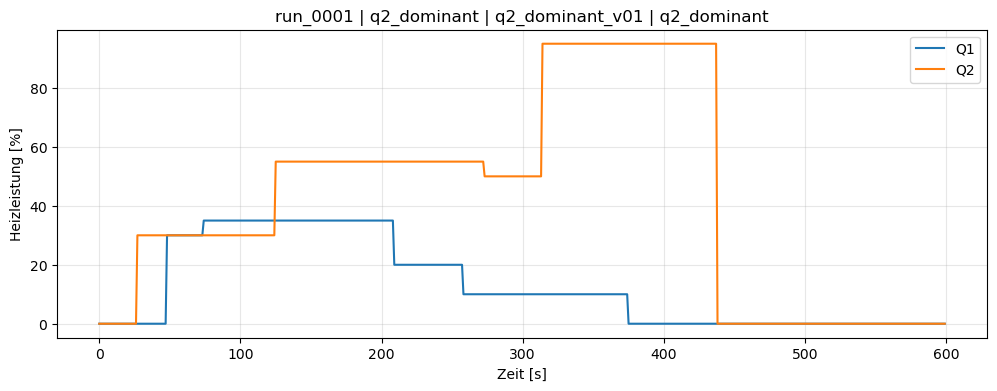

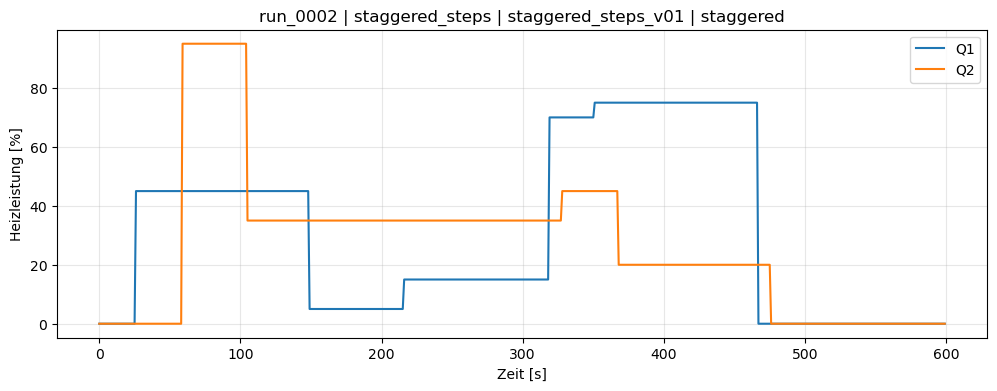

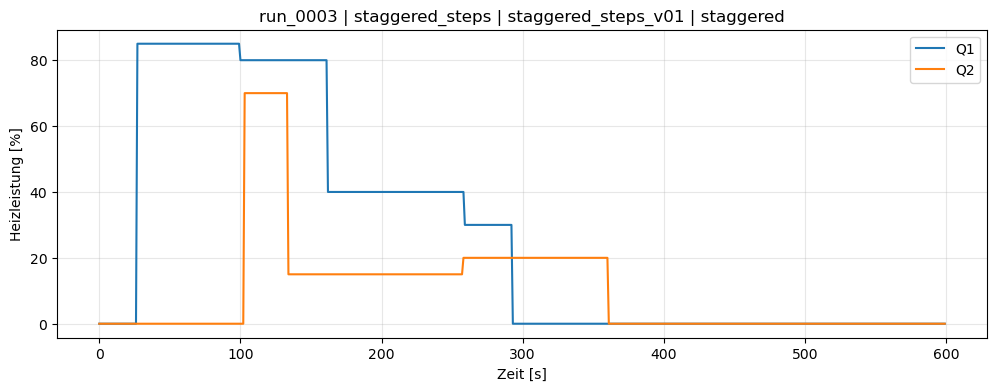

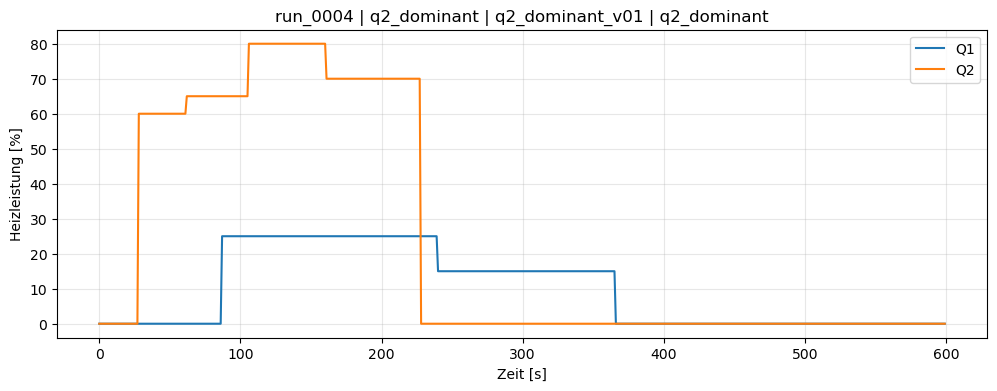

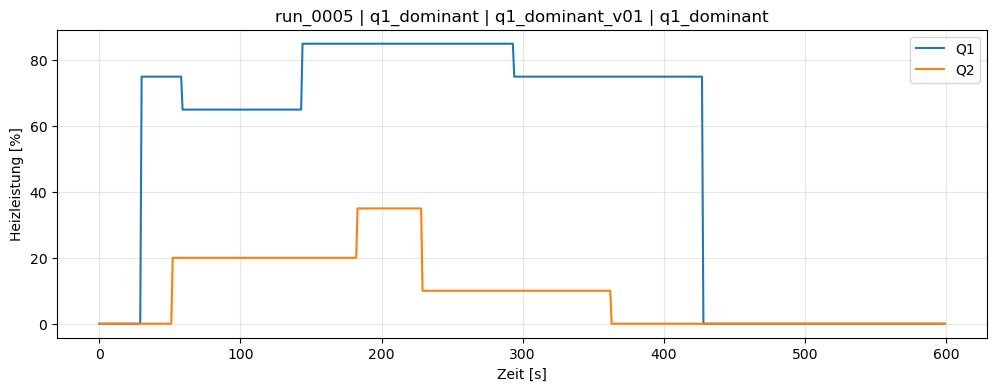

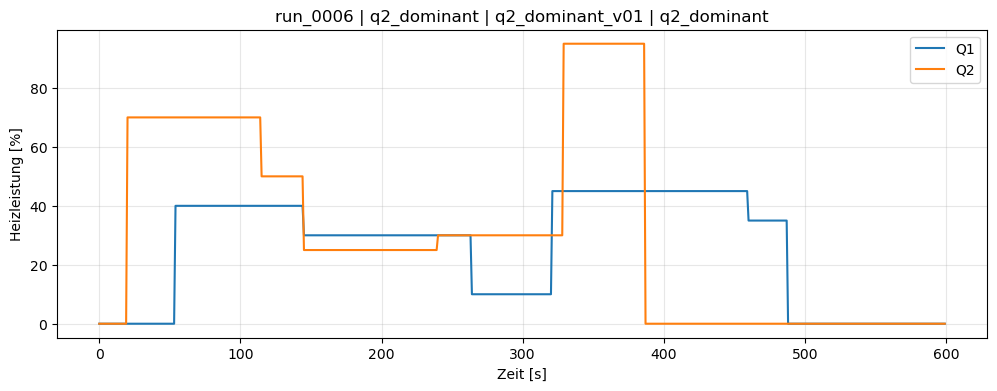

In [21]:
def plot_profile_run(profile_run: ProfileRun) -> None:
    """Plot Q1 and Q2 for one profile run."""
    t = np.arange(len(profile_run.q1), dtype=float)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t, profile_run.q1, label="Q1")
    ax.plot(t, profile_run.q2, label="Q2")
    ax.set_title(
        f"{profile_run.run_id} | {profile_run.profile_family} | "
        f"{profile_run.profile_variant} | {profile_run.coordination_mode}"
    )
    ax.set_xlabel("Zeit [s]")
    ax.set_ylabel("Heizleistung [%]")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


for profile in example_profiles:
    plot_profile_run(profile)


## Simulation mit dem TCLab-Modell

In diesem Abschnitt werden die generierten Heizprofile mit dem TCLab-Modell simuliert. Ziel ist die Erzeugung eines ersten Simulationsdatensatzes für den Normalbetrieb.


In [23]:
# ============================================================
# Modell-Simulation
# ============================================================

def get_tclab_model_class(speedup: int):
    """Return the TCLab emulation class."""
    if not TCLAB_AVAILABLE:
        raise RuntimeError("tclab ist nicht verfügbar.")
    return tclab.setup(connected=False, speedup=speedup)


def simulate_profile_with_tclab_model(
    profile_run: ProfileRun,
    config: Dict[str, Any],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Simulate one profile run with the TCLab emulation."""
    if not TCLAB_AVAILABLE:
        raise RuntimeError("tclab ist nicht verfügbar.")

    run_duration_s = int(config["run_duration_s"])
    sample_time_s = float(config["sample_time_s"])
    speedup = int(config["simulation_speedup"])

    t_axis = build_time_axis(run_duration_s, sample_time_s)
    n_samples = len(t_axis)

    ModelClass = get_tclab_model_class(speedup=speedup)
    records = []

    with ModelClass() as lab:
        ambient_ref = float((lab.T1 + lab.T2) / 2.0)

        for k, t_sec in enumerate(build_clock(n_samples, sample_time_s)):
            q1 = float(profile_run.q1[k])
            q2 = float(profile_run.q2[k])

            lab.Q1(q1)
            lab.Q2(q2)

            T1 = float(lab.T1)
            T2 = float(lab.T2)

            if k < profile_run.initial_hold_s:
                phase = "initial"
            elif k >= n_samples - profile_run.cooldown_s:
                phase = "cooldown"
            else:
                phase = "active"

            records.append({
                "run_id": profile_run.run_id,
                "source": "model",
                "profile_family": profile_run.profile_family,
                "profile_variant": profile_run.profile_variant,
                "sample_time_s": sample_time_s,
                "t_sec": float(t_sec),
                "Q1": q1,
                "Q2": q2,
                "T1": T1,
                "T2": T2,
                "ambient_ref": ambient_ref,
                "phase": phase,
                "split": "unassigned",
                "run_ok": True,
                "notes": "",
            })

        lab.Q1(0)
        lab.Q2(0)

    ts_df = pd.DataFrame(records, columns=TIMESERIES_COLUMNS)

    meta_df = pd.DataFrame([{
        "run_id": profile_run.run_id,
        "source": "model",
        "profile_family": profile_run.profile_family,
        "profile_variant": profile_run.profile_variant,
        "duration_s": run_duration_s,
        "sample_time_s": sample_time_s,
        "initial_hold_s": profile_run.initial_hold_s,
        "cooldown_s": profile_run.cooldown_s,
        "seed": config["random_seed"],
        "ambient_ref_start": ambient_ref,
        "t1_start": float(ts_df["T1"].iloc[0]),
        "t2_start": float(ts_df["T2"].iloc[0]),
        "t1_end": float(ts_df["T1"].iloc[-1]),
        "t2_end": float(ts_df["T2"].iloc[-1]),
        "q1_mean": float(ts_df["Q1"].mean()),
        "q1_max": float(ts_df["Q1"].max()),
        "q2_mean": float(ts_df["Q2"].mean()),
        "q2_max": float(ts_df["Q2"].max()),
        "n_segments_q1": profile_run.n_segments_q1,
        "n_segments_q2": profile_run.n_segments_q2,
        "coordination_mode": profile_run.coordination_mode,
        "contains_short_segment": profile_run.contains_short_segment,
        "profile_signature": profile_run.signature,
        "run_ok": True,
        "comment": "",
    }], columns=RUN_METADATA_COLUMNS)

    return ts_df, meta_df


In [24]:
# ============================================================
# Mehrere Modell-Runs erzeugen
# ============================================================

def generate_model_dataset(
    config: Dict[str, Any],
    rng: np.random.Generator,
) -> Tuple[pd.DataFrame, pd.DataFrame, List[ProfileRun]]:
    """Generate a complete model dataset with multiple runs."""
    all_ts: List[pd.DataFrame] = []
    all_meta: List[pd.DataFrame] = []
    all_profiles: List[ProfileRun] = []
    existing_signatures: List[str] = []

    n_runs = int(config["n_runs_model"])

    for run_idx in range(1, n_runs + 1):
        profile_run = generate_profile_run(
            run_idx=run_idx,
            config=config,
            rng=rng,
            existing_signatures=existing_signatures,
        )
        ts_df, meta_df = simulate_profile_with_tclab_model(profile_run, config)

        all_ts.append(ts_df)
        all_meta.append(meta_df)
        all_profiles.append(profile_run)
        existing_signatures.append(profile_run.signature)

        print(
            f"[{run_idx:02d}/{n_runs:02d}] "
            f"{profile_run.run_id} | {profile_run.profile_family} | {profile_run.coordination_mode}"
        )

    timeseries_df = pd.concat(all_ts, ignore_index=True)
    metadata_df = pd.concat(all_meta, ignore_index=True)

    return timeseries_df, metadata_df, all_profiles


In [25]:
# Diese Zelle nur ausführen, wenn das TCLab-Modell verfügbar ist.

timeseries_model_df = pd.DataFrame(columns=TIMESERIES_COLUMNS)
metadata_model_df = pd.DataFrame(columns=RUN_METADATA_COLUMNS)
model_profiles: List[ProfileRun] = []

if CONFIG["use_model"]:
    timeseries_model_df, metadata_model_df, model_profiles = generate_model_dataset(CONFIG, rng)

print(timeseries_model_df.shape, metadata_model_df.shape)


(0, 15) (0, 25)


## Erste Plausibilitätsprüfung des Simulationsdatensatzes

Im Folgenden werden einige Kennwerte und Beispielplots des generierten Datensatzes geprüft.


In [27]:
metadata_model_df.head()

,run_id,source,profile_family,profile_variant,duration_s,sample_time_s,initial_hold_s,cooldown_s,seed,ambient_ref_start,...,q1_max,q2_mean,q2_max,n_segments_q1,n_segments_q2,coordination_mode,contains_short_segment,profile_signature,run_ok,comment


In [28]:
timeseries_model_df.head()

,run_id,source,profile_family,profile_variant,sample_time_s,t_sec,Q1,Q2,T1,T2,ambient_ref,phase,split,run_ok,notes


In [29]:
if not metadata_model_df.empty:
    display(metadata_model_df.groupby("profile_family").size().rename("n_runs").to_frame())


In [30]:
def plot_simulation_run(timeseries_df: pd.DataFrame, run_id: str) -> None:
    """Plot one simulated run with Q1, Q2, T1 and T2."""
    df = timeseries_df[timeseries_df["run_id"] == run_id].copy()

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(df["t_sec"], df["Q1"], label="Q1")
    axes[0].plot(df["t_sec"], df["Q2"], label="Q2")
    axes[0].set_ylabel("Heizleistung [%]")
    axes[0].set_title(f"Run: {run_id}")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(df["t_sec"], df["T1"], label="T1")
    axes[1].plot(df["t_sec"], df["T2"], label="T2")
    axes[1].set_xlabel("Zeit [s]")
    axes[1].set_ylabel("Temperatur [°C]")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.show()


for run_id in metadata_model_df["run_id"].head(CONFIG["plot_example_runs"]).tolist():
    plot_simulation_run(timeseries_model_df, run_id)


In [31]:
def plot_family_overlays(
    timeseries_df: pd.DataFrame,
    metadata_df: pd.DataFrame,
    max_runs_per_family: int = 5,
) -> None:
    """Overlay T1 and T2 per profile family."""
    families = metadata_df["profile_family"].dropna().unique().tolist()

    for family in families:
        run_ids = metadata_df.loc[
            metadata_df["profile_family"] == family, "run_id"
        ].head(max_runs_per_family).tolist()

        fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

        for run_id in run_ids:
            df = timeseries_df[timeseries_df["run_id"] == run_id]
            axes[0].plot(df["t_sec"], df["T1"], alpha=0.8, label=run_id)
            axes[1].plot(df["t_sec"], df["T2"], alpha=0.8, label=run_id)

        axes[0].set_title(f"Familie: {family} | T1")
        axes[1].set_title(f"Familie: {family} | T2")
        axes[1].set_xlabel("Zeit [s]")
        axes[0].set_ylabel("Temperatur [°C]")
        axes[1].set_ylabel("Temperatur [°C]")

        for ax in axes:
            ax.grid(True, alpha=0.3)

        axes[0].legend(loc="best", fontsize=8)
        plt.tight_layout()
        plt.show()


if CONFIG["plot_family_overlays"] and not metadata_model_df.empty:
    plot_family_overlays(
        timeseries_model_df,
        metadata_model_df,
        max_runs_per_family=CONFIG["max_overlay_runs_per_family"],
    )


## Export des Datensatzes

Die erzeugten Daten werden für die spätere Weiterverarbeitung gespeichert.

Geplant sind:
- Zeitreihendaten im Parquet-Format
- Run-Metadaten im Parquet-Format
- JSON-Dateien mit Konfiguration und Profilbibliothek


In [33]:
# ============================================================
# Exportfunktionen
# ============================================================

def write_dataframe_with_fallback(
    df: pd.DataFrame,
    parquet_path: Path,
    csv_path: Path,
    write_parquet: bool = True,
    write_csv_fallback: bool = True,
) -> None:
    """Write a DataFrame as parquet and optionally as CSV fallback."""
    parquet_path.parent.mkdir(parents=True, exist_ok=True)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    if write_parquet:
        try:
            df.to_parquet(parquet_path, index=False)
            print("Parquet geschrieben:", parquet_path)
        except Exception as exc:
            print("Parquet fehlgeschlagen:", exc)

    if write_csv_fallback:
        df.to_csv(csv_path, index=False)
        print("CSV geschrieben:", csv_path)


def export_dataset_artifacts(
    timeseries_df: pd.DataFrame,
    metadata_df: pd.DataFrame,
    config: Dict[str, Any],
    profile_library: Dict[str, Dict[str, Any]],
) -> None:
    """Export timeseries, metadata, config and profile library."""
    if timeseries_df.empty and metadata_df.empty:
        print("Keine Daten zum Export vorhanden.")
        return

    if not timeseries_df.empty:
        for source_value in sorted(timeseries_df["source"].dropna().unique().tolist()):
            part_df = timeseries_df[timeseries_df["source"] == source_value].copy()

            parquet_path = TIMESERIES_DIR / f"source={source_value}" / "part-0000.parquet"
            csv_path = TIMESERIES_DIR / f"source={source_value}" / "part-0000.csv"

            write_dataframe_with_fallback(
                df=part_df,
                parquet_path=parquet_path,
                csv_path=csv_path,
                write_parquet=config["write_parquet"],
                write_csv_fallback=config["write_csv_fallback"],
            )

    if not metadata_df.empty:
        for source_value in sorted(metadata_df["source"].dropna().unique().tolist()):
            part_df = metadata_df[metadata_df["source"] == source_value].copy()

            parquet_path = METADATA_DIR / f"source={source_value}" / "run_metadata.parquet"
            csv_path = METADATA_DIR / f"source={source_value}" / "run_metadata.csv"

            write_dataframe_with_fallback(
                df=part_df,
                parquet_path=parquet_path,
                csv_path=csv_path,
                write_parquet=config["write_parquet"],
                write_csv_fallback=config["write_csv_fallback"],
            )

    if config["write_json_config"]:
        with open(CONFIG_DIR / "notebook_config.json", "w", encoding="utf-8") as f:
            json.dump(config, f, indent=2, ensure_ascii=False)

        with open(CONFIG_DIR / "profile_library.json", "w", encoding="utf-8") as f:
            json.dump(profile_library, f, indent=2, ensure_ascii=False)

        print("JSON-Dateien geschrieben.")


In [34]:
if CONFIG["use_model"] and not timeseries_model_df.empty:
    export_dataset_artifacts(
        timeseries_df=timeseries_model_df,
        metadata_df=metadata_model_df,
        config=CONFIG,
        profile_library=PROFILE_LIBRARY,
    )


## Optionaler Hardwaremodus

In diesem Abschnitt wird dieselbe Profilbibliothek optional auf echter TCLab-Hardware gefahren.

Ziele:
- gleiche Profilstruktur wie im Modell
- gleiche Datenstruktur wie im Modell
- automatische Serienmessung mehrerer Runs
- Start eines neuen Runs nur bei geeignetem Ausgangszustand


In [36]:
# ============================================================
# Hardware-Hilfsfunktionen
# ============================================================

def measure_ambient_reference(lab, n_samples: int = 10, wait_s: float = 1.0):
    """Estimate separate ambient references for T1 and T2."""
    t1_vals = []
    t2_vals = []
    for _ in range(n_samples):
        t1_vals.append(float(lab.T1))
        t2_vals.append(float(lab.T2))
        time.sleep(wait_s)
    return float(np.mean(t1_vals)), float(np.mean(t2_vals))


def get_hardware_ready_status(
    lab,
    ambient_t1_ref: float,
    ambient_t2_ref: float,
    tolerance_degC: float,
    stability_window_s: int,
    max_slope_degC_per_s: float,
):
    """Return detailed readiness status for the hardware."""
    t1_values = []
    t2_values = []

    for _ in range(stability_window_s):
        t1_values.append(float(lab.T1))
        t2_values.append(float(lab.T2))
        time.sleep(1.0)

    t1_values = np.array(t1_values, dtype=float)
    t2_values = np.array(t2_values, dtype=float)
    t = np.arange(len(t1_values), dtype=float)

    slope_t1 = np.polyfit(t, t1_values, 1)[0] if len(t1_values) >= 2 else 0.0
    slope_t2 = np.polyfit(t, t2_values, 1)[0] if len(t2_values) >= 2 else 0.0

    t1_dev_max = float(np.max(np.abs(t1_values - ambient_t1_ref)))
    t2_dev_max = float(np.max(np.abs(t2_values - ambient_t2_ref)))

    t1_ok = t1_dev_max <= tolerance_degC
    t2_ok = t2_dev_max <= tolerance_degC
    stable_ok = (abs(slope_t1) <= max_slope_degC_per_s) and (abs(slope_t2) <= max_slope_degC_per_s)

    ready = bool(t1_ok and t2_ok and stable_ok)

    return {
        "ready": ready,
        "t1_mean": float(np.mean(t1_values)),
        "t2_mean": float(np.mean(t2_values)),
        "t1_dev_max": t1_dev_max,
        "t2_dev_max": t2_dev_max,
        "slope_t1": float(slope_t1),
        "slope_t2": float(slope_t2),
    }

In [37]:
def acquire_one_hardware_run(
    lab,
    profile_run: ProfileRun,
    config: Dict[str, Any],
    ambient_ref: float,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Run one profile on real hardware and collect the data."""
    run_duration_s = int(config["run_duration_s"])
    sample_time_s = float(config["sample_time_s"])

    t_axis = build_time_axis(run_duration_s, sample_time_s)
    q1_arr = np.asarray(profile_run.q1, dtype=float)
    q2_arr = np.asarray(profile_run.q2, dtype=float)

    n_samples = len(t_axis)

    if len(q1_arr) != n_samples or len(q2_arr) != n_samples:
        raise ValueError(
            f"Profil-Länge passt nicht zur Zeitachse: "
            f"len(t_axis)={n_samples}, len(q1)={len(q1_arr)}, len(q2)={len(q2_arr)}"
        )

    initial_hold_n = int(round(profile_run.initial_hold_s / sample_time_s))
    cooldown_n = int(round(profile_run.cooldown_s / sample_time_s))

    records = []
    progress_every_s = 30
    progress_every_n = max(1, int(round(progress_every_s / sample_time_s)))

    print(
        f"  Starte Messung: {profile_run.run_id} | "
        f"Dauer ca. {run_duration_s} s | "
        f"Profil: {profile_run.profile_family} / {profile_run.profile_variant}",
        flush=True
    )

    clock_iter = iter(build_clock(n_samples, sample_time_s))

    try:
        for k, (t_nom, q1, q2) in enumerate(zip(t_axis, q1_arr, q2_arr)):
            _ = next(clock_iter)   # Hardware-Takt nur zum Warten / Pacing

            lab.Q1(float(q1))
            lab.Q2(float(q2))

            T1 = float(lab.T1)
            T2 = float(lab.T2)

            if k < initial_hold_n:
                phase = "initial"
            elif k >= n_samples - cooldown_n:
                phase = "cooldown"
            else:
                phase = "active"

            records.append({
                "run_id": profile_run.run_id,
                "source": "hardware",
                "profile_family": profile_run.profile_family,
                "profile_variant": profile_run.profile_variant,
                "sample_time_s": sample_time_s,
                "t_sec": float(t_nom),
                "Q1": float(q1),
                "Q2": float(q2),
                "T1": T1,
                "T2": T2,
                "ambient_ref": ambient_ref,
                "phase": phase,
                "split": "unassigned",
                "run_ok": True,
                "notes": "",
            })

            if (k == 0) or ((k + 1) % progress_every_n == 0) or (k == n_samples - 1):
                print(
                    f"    Fortschritt: {k+1}/{n_samples} Samples | "
                    f"t={t_nom:.0f} s | T1={T1:.2f} °C | T2={T2:.2f} °C | "
                    f"Q1={q1:.1f} | Q2={q2:.1f}",
                    flush=True
                )

    finally:
        lab.Q1(0)
        lab.Q2(0)

    ts_df = pd.DataFrame(records, columns=TIMESERIES_COLUMNS)

    meta_df = pd.DataFrame([{
        "run_id": profile_run.run_id,
        "source": "hardware",
        "profile_family": profile_run.profile_family,
        "profile_variant": profile_run.profile_variant,
        "duration_s": run_duration_s,
        "sample_time_s": sample_time_s,
        "initial_hold_s": profile_run.initial_hold_s,
        "cooldown_s": profile_run.cooldown_s,
        "seed": config["random_seed"],
        "ambient_ref_start": ambient_ref,
        "t1_start": float(ts_df["T1"].iloc[0]),
        "t2_start": float(ts_df["T2"].iloc[0]),
        "t1_end": float(ts_df["T1"].iloc[-1]),
        "t2_end": float(ts_df["T2"].iloc[-1]),
        "q1_mean": float(ts_df["Q1"].mean()),
        "q1_max": float(ts_df["Q1"].max()),
        "q2_mean": float(ts_df["Q2"].mean()),
        "q2_max": float(ts_df["Q2"].max()),
        "n_segments_q1": profile_run.n_segments_q1,
        "n_segments_q2": profile_run.n_segments_q2,
        "coordination_mode": profile_run.coordination_mode,
        "contains_short_segment": profile_run.contains_short_segment,
        "profile_signature": profile_run.signature,
        "run_ok": True,
        "comment": "",
    }], columns=RUN_METADATA_COLUMNS)

    return ts_df, meta_df

In [38]:
def generate_hardware_dataset(
    config: Dict[str, Any],
    rng: np.random.Generator,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Automatically acquire multiple hardware runs."""
    if not TCLAB_AVAILABLE:
        raise RuntimeError("tclab ist nicht verfügbar.")

    all_ts: List[pd.DataFrame] = []
    all_meta: List[pd.DataFrame] = []
    existing_signatures: List[str] = []

    n_runs = int(config["n_runs_hardware"])

    with tclab.TCLab() as lab:
        lab.Q1(0)
        lab.Q2(0)

        ambient_t1_ref, ambient_t2_ref = measure_ambient_reference(lab, n_samples=10, wait_s=1.0)
        ambient_ref = float((ambient_t1_ref + ambient_t2_ref) / 2.0)

        print(f"Referenztemperaturen: T1={ambient_t1_ref:.2f} °C | T2={ambient_t2_ref:.2f} °C", flush=True)

        for run_idx in range(1, n_runs + 1):
            print(f"\nWarte auf Startfreigabe für Hardware-Run {run_idx}/{n_runs} ...", flush=True)

            while True:
                status = get_hardware_ready_status(
                    lab=lab,
                    ambient_t1_ref=ambient_t1_ref,
                    ambient_t2_ref=ambient_t2_ref,
                    tolerance_degC=config["hardware_start_temp_tolerance_degC"],
                    stability_window_s=config["hardware_stability_window_s"],
                    max_slope_degC_per_s=config["hardware_stability_max_slope_degC_per_s"],
                )

                print(
                    f"  Check | "
                    f"T1_mean={status['t1_mean']:.2f} °C, max_dev={status['t1_dev_max']:.2f}, slope={status['slope_t1']:.4f} | "
                    f"T2_mean={status['t2_mean']:.2f} °C, max_dev={status['t2_dev_max']:.2f}, slope={status['slope_t2']:.4f}",
                    flush=True
                )

                if status["ready"]:
                    print(f"  Freigabe erteilt für Run {run_idx}/{n_runs}.", flush=True)
                    break

                print("  Noch nicht freigegeben. Warte weiter ...", flush=True)
                time.sleep(config["hardware_wait_check_interval_s"])

            profile_run = generate_profile_run(
                run_idx=run_idx,
                config=config,
                rng=rng,
                existing_signatures=existing_signatures,
            )

            ts_df, meta_df = acquire_one_hardware_run(
                lab=lab,
                profile_run=profile_run,
                config=config,
                ambient_ref=ambient_ref,
            )

            all_ts.append(ts_df)
            all_meta.append(meta_df)
            existing_signatures.append(profile_run.signature)

            print(f"  Run abgeschlossen: {profile_run.run_id} | {profile_run.profile_family}", flush=True)

        lab.Q1(0)
        lab.Q2(0)

    timeseries_df = (
        pd.concat(all_ts, ignore_index=True)
        if all_ts else pd.DataFrame(columns=TIMESERIES_COLUMNS)
    )
    metadata_df = (
        pd.concat(all_meta, ignore_index=True)
        if all_meta else pd.DataFrame(columns=RUN_METADATA_COLUMNS)
    )

    return timeseries_df, metadata_df

In [39]:
# Diese Zelle nur gezielt aktivieren, wenn echte Hardware verwendet werden soll.

timeseries_hardware_df = pd.DataFrame(columns=TIMESERIES_COLUMNS)
metadata_hardware_df = pd.DataFrame(columns=RUN_METADATA_COLUMNS)

# Beispiel:
#CONFIG["use_hardware"] = True
#CONFIG["n_runs_hardware"] = 3

if CONFIG["use_hardware"] and CONFIG["n_runs_hardware"] > 0:
    timeseries_hardware_df, metadata_hardware_df = generate_hardware_dataset(CONFIG, rng)

print(timeseries_hardware_df.shape, metadata_hardware_df.shape)


TCLab version 1.0.0
Arduino Leonardo connected on port COM4 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
Referenztemperaturen: T1=19.25 °C | T2=18.36 °C

Warte auf Startfreigabe für Hardware-Run 1/24 ...
  Check | T1_mean=19.23 °C, max_dev=0.15, slope=-0.0059 | T2_mean=18.35 °C, max_dev=0.06, slope=-0.0032
  Freigabe erteilt für Run 1/24.
  Starte Messung: run_0001 | Dauer ca. 600 s | Profil: q2_dominant / q2_dominant_v01
    Fortschritt: 1/600 Samples | t=0 s | T1=19.13 °C | T2=18.32 °C | Q1=0.0 | Q2=0.0
    Fortschritt: 30/600 Samples | t=29 s | T1=19.25 °C | T2=18.64 °C | Q1=0.0 | Q2=65.0
    Fortschritt: 60/600 Samples | t=59 s | T1=19.29 °C | T2=19.90 °C | Q1=30.0 | Q2=65.0
    Fortschritt: 90/600 Samples | t=89 s | T1=21.29 °C | T2=22.54 °C | Q1=30.0 | Q2=35.0
    Fortschritt: 120/600 Samples | t=119 s | T1=24.19 °C | T2=25.22 °C | Q1=30.0 | Q2=35.0
    Fortschritt: 150/600 Samples | t=149 s | T1=27.05 °C | T2=27.21 °C | Q1=30.0 | Q2=35.0
    Fortschritt: 180/600 

In [40]:
# Optionaler Export der Hardwaredaten

if CONFIG["use_hardware"] and not timeseries_hardware_df.empty:
    export_dataset_artifacts(
        timeseries_df=timeseries_hardware_df,
        metadata_df=metadata_hardware_df,
        config=CONFIG,
        profile_library=PROFILE_LIBRARY,
    )


Parquet geschrieben: data\v1\timeseries\source=hardware\part-0000.parquet
CSV geschrieben: data\v1\timeseries\source=hardware\part-0000.csv
Parquet geschrieben: data\v1\run_metadata\source=hardware\run_metadata.parquet
CSV geschrieben: data\v1\run_metadata\source=hardware\run_metadata.csv
JSON-Dateien geschrieben.


## Abschluss

In diesem Notebook wurde eine erste strukturierte Bibliothek von Normalbetriebsdaten für das TCLab aufgebaut.

Ergebnisse dieses Notebooks:

- definierte Profilbibliothek für $Q_1$ und $Q_2$
- Datengenerierung mit dem TCLab-Modell
- optional dieselbe Logik für reale Hardware
- einheitliches Speicherformat für spätere ML- und DL-Notebooks
